In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('nyc_events_filtered.csv')

In [12]:
df.head()

,Event ID,Event Name,Start Date/Time,End Date/Time,Event Agency,Event Type,Event Borough,Event Location,Event Street Side,Street Closure Type,Community Board,Police Precinct,Month,Month Name
0,330659,West Dalehead Arch Landscape Restoration,2017-06-01,06/01/2017 11:59:00 PM,Parks Department,Construction,Manhattan,Central Park: West Dalehead Arch,NaN,NaN,"64,","22,",6,June
1,346700,Overflow Parking for Scooper Bowl New York,2017-06-01,06/03/2017 11:00:00 PM,Street Activity Permit Office,Production Event,Manhattan,AVENUE OF THE AMERICAS between WEST 41 STRE...,West,Curb Lane Only,"5,","14,",6,June
2,342517,PE Classes,2017-06-01,06/01/2017 01:00:00 AM,Parks Department,Special Event,Bronx,"Crotona Park: Crotona Park ,Crotona Park: Socc...",NaN,NaN,"03, 3,","42,",6,June
3,337463,Scooper Bowl,2017-06-01,06/01/2017 11:59:00 PM,Parks Department,Special Event,Manhattan,Bryant Park: Fountain Terrace,NaN,NaN,"5,","14,",6,June
4,338396,Skate Park Construction,2017-06-01,06/01/2017 11:59:00 PM,Parks Department,Special Event,Manhattan,"Thomas Jefferson Park: 114 St-Basketball-03 ,T...",NaN,NaN,"11,","23,",6,June


In [6]:
df.columns

Index(['Event ID', 'Event Name', 'Start Date/Time', 'End Date/Time',
       'Event Agency', 'Event Type', 'Event Borough', 'Event Location',
       'Event Street Side', 'Street Closure Type', 'Community Board',
       'Police Precinct'],
      dtype='object')

In [7]:
df['Start Date/Time'] = pd.to_datetime(df['Start Date/Time'])
df['Month'] = df['Start Date/Time'].dt.month
month_map = {6: 'June', 8: 'August', 10: 'October', 12: 'December'}
df['Month Name'] = df['Month'].map(month_map)
df = df[df['Month'].isin([6, 8, 10, 12])]

month_order = ['June', 'August', 'October', 'December']
df['Month Name'] = pd.Categorical(df['Month Name'], categories=month_order, ordered=True)

C:\Users\billy\AppData\Local\Temp\ipykernel_26920\2931787850.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Start Date/Time'] = pd.to_datetime(df['Start Date/Time'])


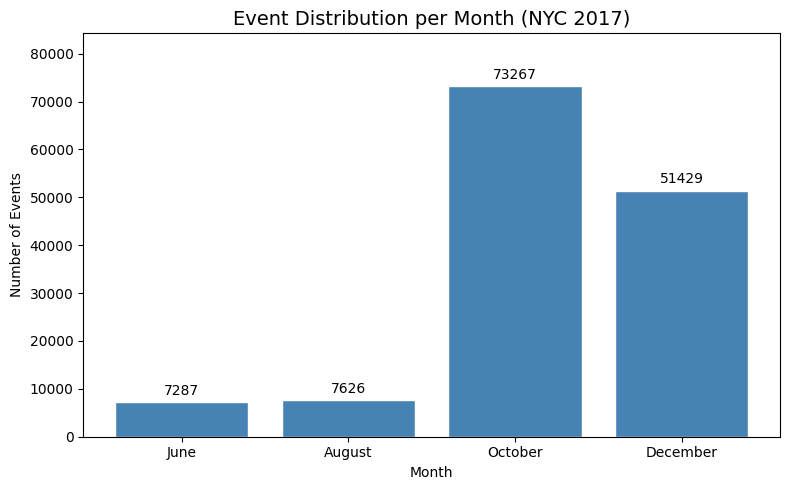

In [8]:
monthly_counts = df.groupby('Month Name', observed=True).size()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(monthly_counts.index, monthly_counts.values, color='steelblue', edgecolor='white')

ax.bar_label(bars, padding=3)
ax.set_title('Event Distribution per Month (NYC 2017)', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Events')
ax.set_ylim(0, monthly_counts.max() * 1.15)
plt.tight_layout()
plt.savefig("event_distribution.png", dpi=150)
plt.show()

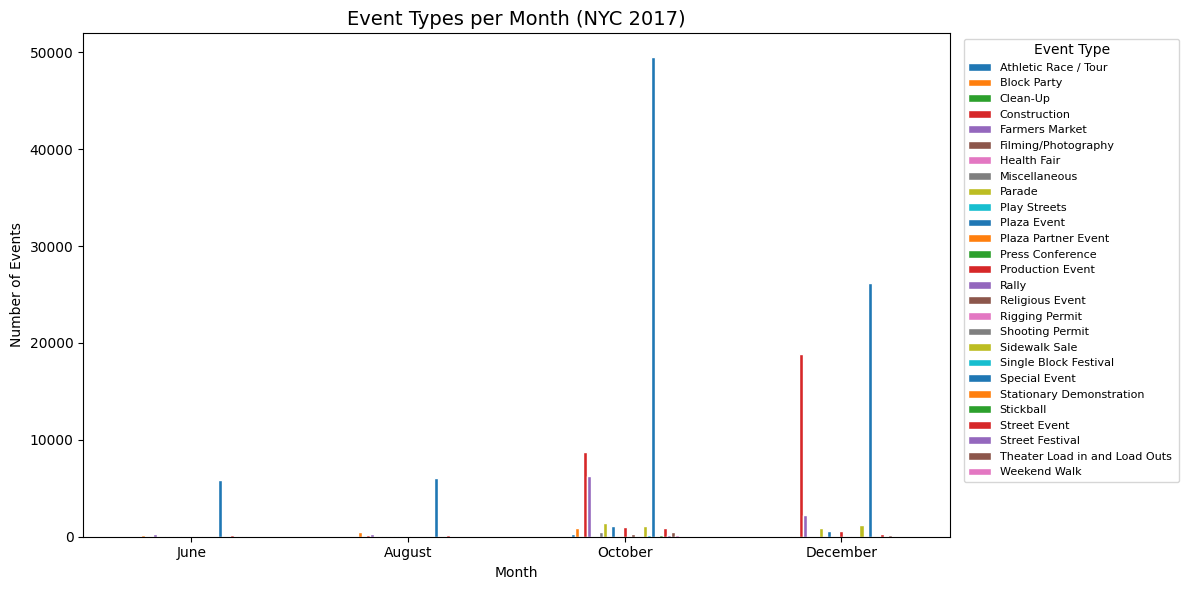

In [9]:
type_month = df.groupby(['Month Name', 'Event Type'], observed=True).size().unstack(fill_value=0)
type_month = type_month.reindex(month_order)

fig, ax = plt.subplots(figsize=(12, 6))
type_month.plot(kind='bar', ax=ax, edgecolor='white')

ax.set_title('Event Types per Month (NYC 2017)', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Events')
ax.set_xticklabels(month_order, rotation=0)
ax.legend(title='Event Type', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("event_types_by_month.png", dpi=150)
plt.show()

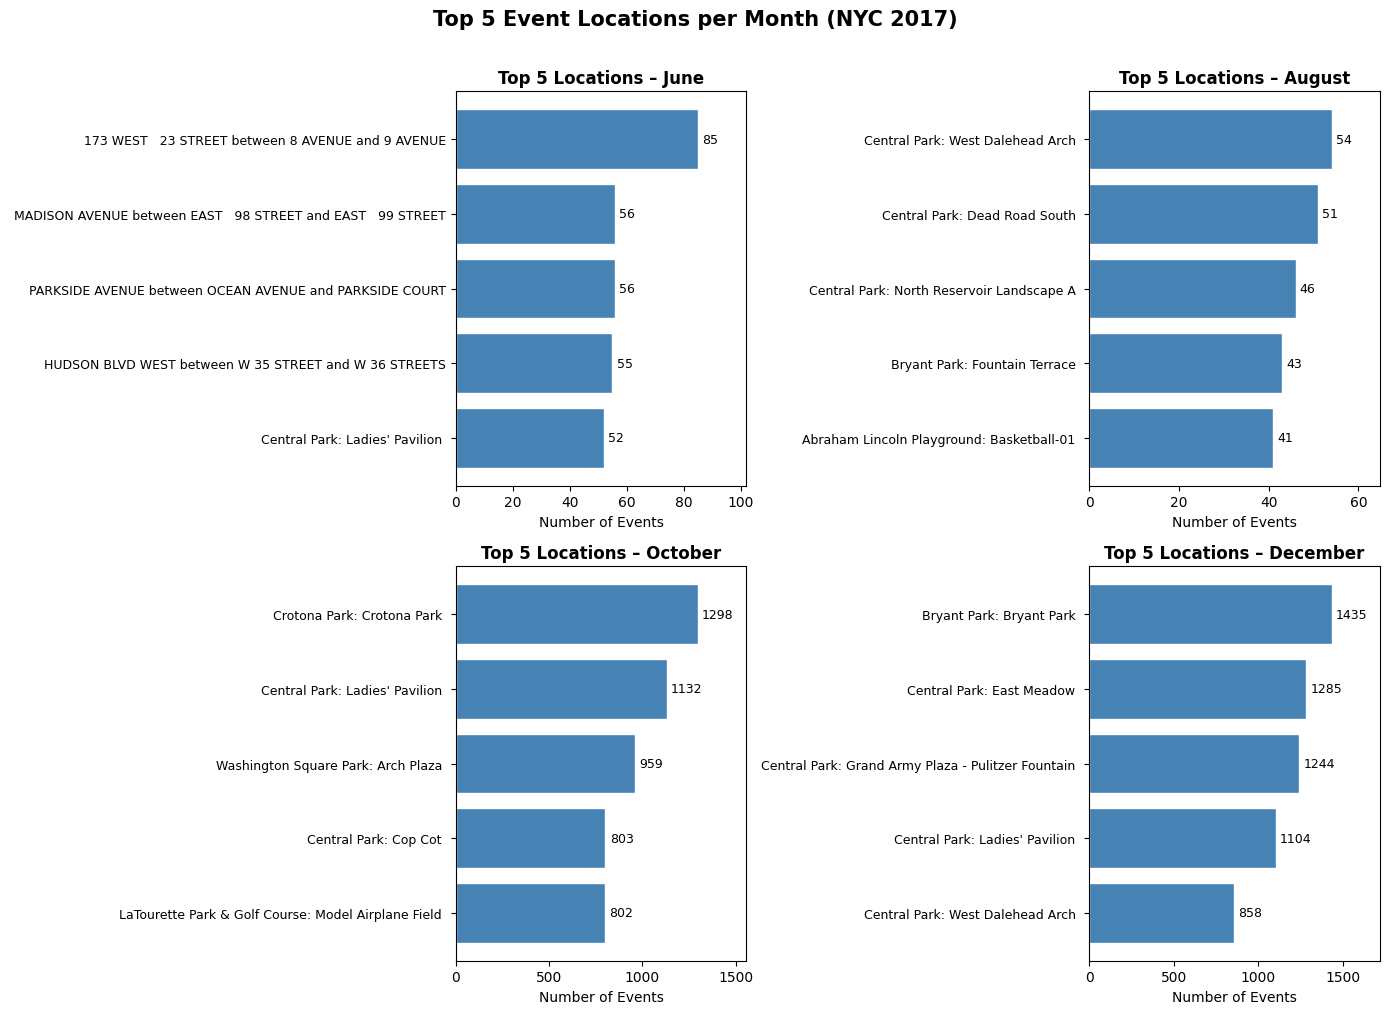

In [13]:
# Get top 5 locations per month
location_month = df.groupby(['Month Name', 'Event Location'], observed=True).size().reset_index(name='Count')

top5_locations = (
    location_month
    .sort_values(['Month Name', 'Count'], ascending=[True, False])
    .groupby('Month Name', observed=True)
    .head(5)
    .reset_index(drop=True)
)

months = ['June', 'August', 'October', 'December']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, month in enumerate(months):
    data = top5_locations[top5_locations['Month Name'] == month].sort_values('Count')
    ax = axes[i]
    bars = ax.barh(data['Event Location'], data['Count'], color='steelblue', edgecolor='white')
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_title(f'Top 5 Locations – {month}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Events')
    ax.set_xlim(0, data['Count'].max() * 1.2)
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Top 5 Event Locations per Month (NYC 2017)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("top5_locations_by_month.png", dpi=150, bbox_inches='tight')
plt.show()

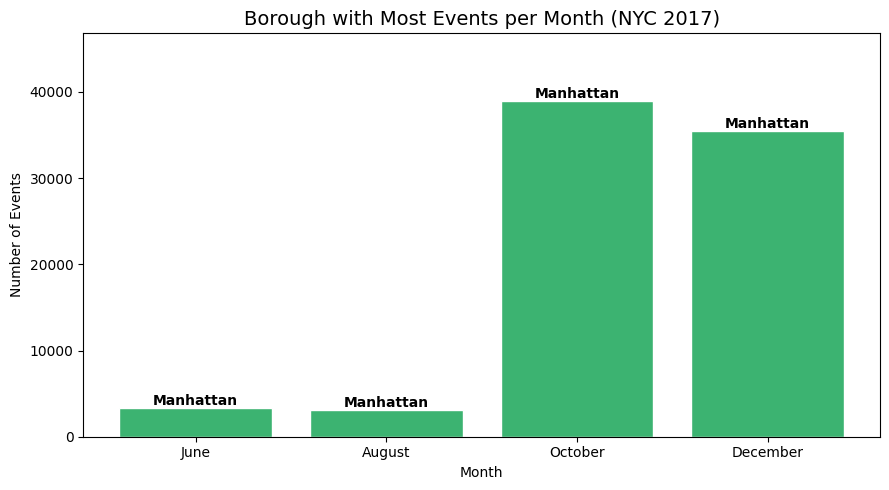

In [11]:
borough_month = df.groupby(['Month Name', 'Event Borough'], observed=True).size().reset_index(name='Count')
top_boroughs = (
    borough_month
    .sort_values('Count', ascending=False)
    .groupby('Month Name', observed=True)
    .first()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(top_boroughs['Month Name'], top_boroughs['Count'],
              color='mediumseagreen', edgecolor='white')

for bar, label in zip(bars, top_boroughs['Event Borough']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            label, ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Borough with Most Events per Month (NYC 2017)', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Events')
ax.set_ylim(0, top_boroughs['Count'].max() * 1.2)
plt.tight_layout()
plt.savefig("top_borough_by_month.png", dpi=150)
plt.show()

### BROOKLYN BITCHES

In [15]:
brooklyn = df[df['Event Borough'].str.upper() == 'BROOKLYN'].copy()

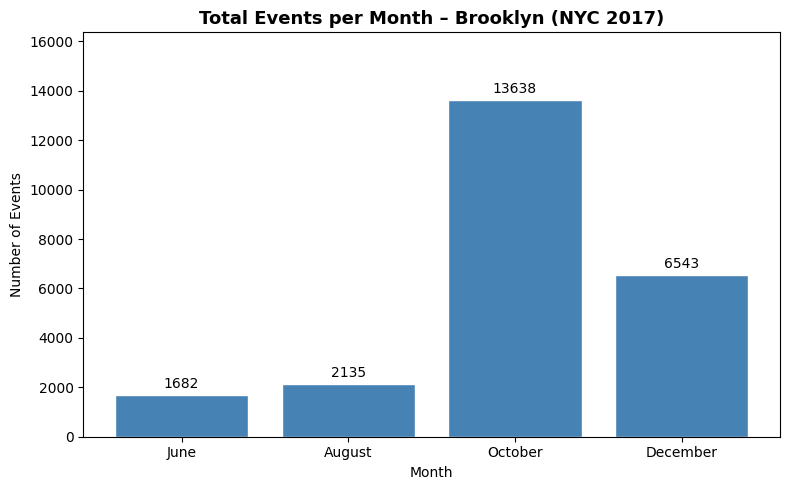

In [16]:
bk_monthly = brooklyn.groupby('Month Name', observed=True).size()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(bk_monthly.index, bk_monthly.values, color='steelblue', edgecolor='white')
ax.bar_label(bars, padding=3)
ax.set_title('Total Events per Month – Brooklyn (NYC 2017)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Events')
ax.set_ylim(0, bk_monthly.max() * 1.2)
plt.tight_layout()
plt.savefig("bk_monthly_counts.png", dpi=150)
plt.show()

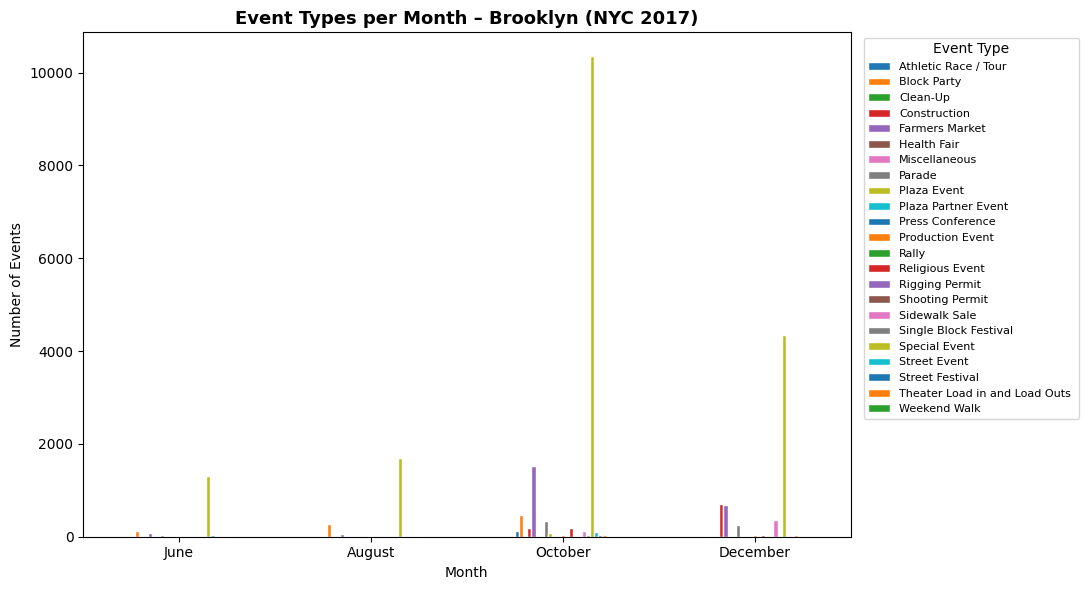

In [17]:
bk_types = brooklyn.groupby(['Month Name', 'Event Type'], observed=True).size().unstack(fill_value=0)
bk_types = bk_types.reindex(month_order)

fig, ax = plt.subplots(figsize=(11, 6))
bk_types.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Event Types per Month – Brooklyn (NYC 2017)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Events')
ax.set_xticklabels(month_order, rotation=0)
ax.legend(title='Event Type', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("bk_event_types.png", dpi=150, bbox_inches='tight')
plt.show()

C:\Users\billy\AppData\Local\Temp\ipykernel_26920\3234232044.py:25: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


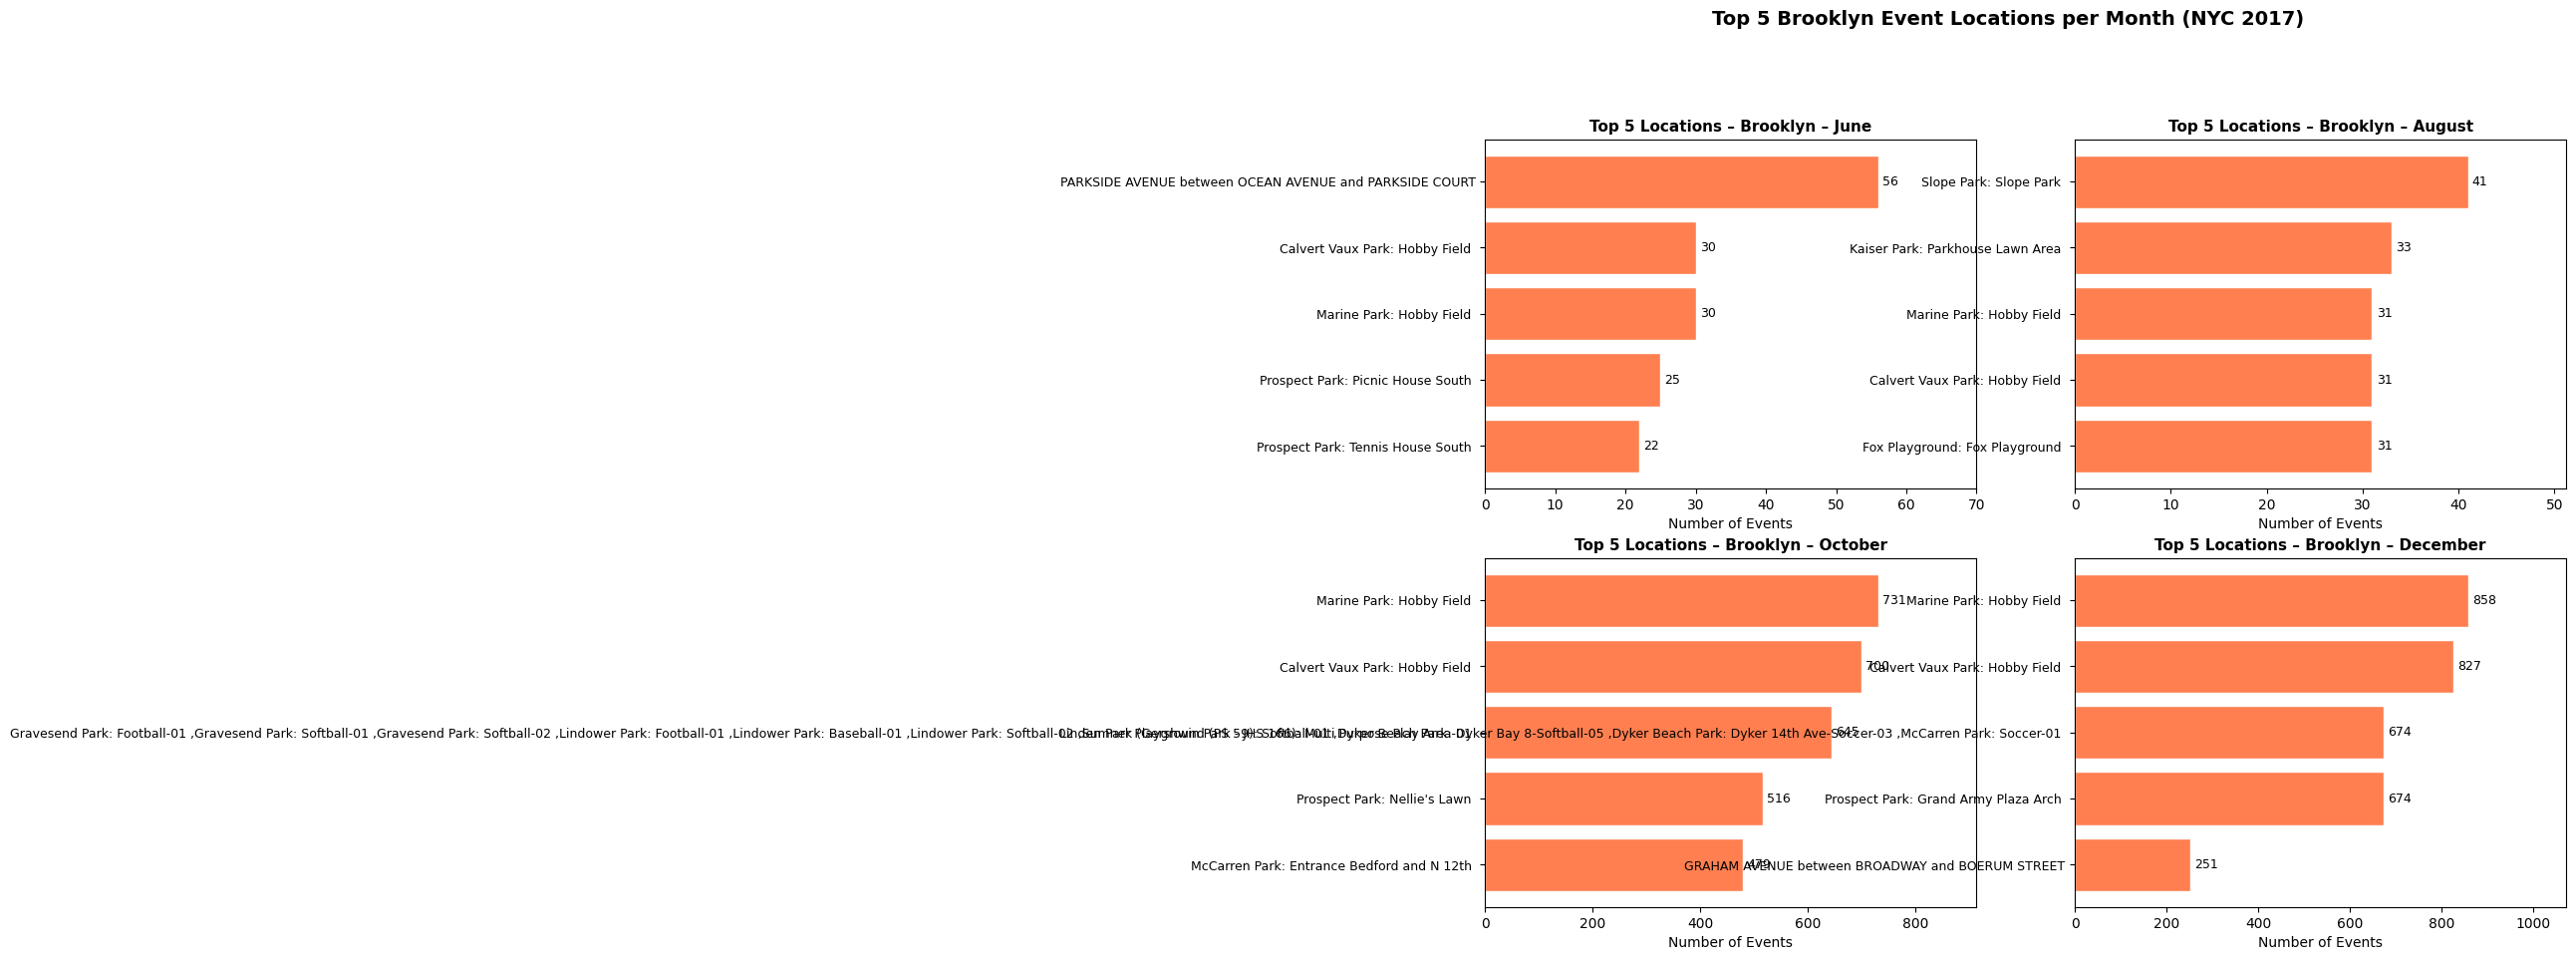

In [18]:
bk_locs = brooklyn.groupby(['Month Name', 'Event Location'], observed=True).size().reset_index(name='Count')

bk_top5 = (
    bk_locs
    .sort_values(['Month Name', 'Count'], ascending=[True, False])
    .groupby('Month Name', observed=True)
    .head(5)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, month in enumerate(month_order):
    data = bk_top5[bk_top5['Month Name'] == month].sort_values('Count')
    ax = axes[i]
    bars = ax.barh(data['Event Location'], data['Count'], color='coral', edgecolor='white')
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_title(f'Top 5 Locations – Brooklyn – {month}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Number of Events')
    ax.set_xlim(0, data['Count'].max() * 1.25)
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Top 5 Brooklyn Event Locations per Month (NYC 2017)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("bk_top5_locations.png", dpi=150, bbox_inches='tight')
plt.show()